#Concrete Compressive Strength Prediction
  **Life cycle of Machine learning Project**


*   Understanding the Problem Statement
*   Data Collection
*   Data Checks to perform
*   Exploratory data analysis
*   Data Pre-Processing
*   Model Training
*   Choose best model


##1) Problem statement


*   This project understands how the compressive strength of concrete is affected by different components of the concrete mixture such as cement content, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and the age of the concrete.
*   The goal is to analyze how these variables influence the strength of concrete and build a machine learning model that can predict the compressive strength based on the mixture composition.

##2) Data collection


*   data source-https://figshare.unimelb.edu.au/articles/dataset/Compressive_strength_dataset_of_foamed_normal_concrete_for_prediction_model/7028369?file=13603310
*   The data consists of 9 columns and 1133 rows








##2.1 Importing Required Libraries




In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Importing the excel data as Pandas DataFrame

In [5]:
data_path = "/content/Dataset2.xlsx"
col_names = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_Strength']
df = pd.read_excel(data_path,names=col_names)

ShowTop 5 Records

In [6]:
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength
0,336.0,0.0,0.0,182.0,3.0,986.0,817.0,28,44.864203
1,140.1,4.2,215.9,193.9,4.7,1049.5,710.1,28,26.420000
2,350.0,0.0,0.0,203.0,0.0,974.0,775.0,14,22.532076
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,28,42.080000
4,225.0,0.0,0.0,181.0,0.0,1113.0,833.0,7,11.169511


Shape of the dataset

In [7]:
df.shape

(1133, 9)

##2.2 Dataset information


*  Cement: The quantity of cement used in the concrete mixture, which serves as the binding agent.

* Blast Furnace Slag: The amount of blast furnace slag, a supplementary cementitious material, included in the mixture to enhance durability and workability.

* Fly Ash: The proportion of fly ash, another commonly used supplementary cementitious material, which contributes to improved strength and reduced environmental impact.

* Water: The volume of water added to the mixture to achieve the desired consistency and hydration of cement particles.

* Superplasticizer: The dosage of superplasticizer, an additive used to enhance workability and reduce water content while maintaining fluidity.

* Coarse Aggregate: The quantity of coarse aggregate, typically gravel or crushed stone, included in the mixture to provide strength and stability.

* Fine Aggregate: The amount of fine aggregate, such as sand or crushed stone dust, used to fill voids and improve cohesion in the concrete matrix.

* Age (Days): The age of the concrete specimen at the time of testing, which influences its strength development over time.

* Concrete Strength (MPa): The compressive strength of the concrete specimen, measured in megapascals (MPa), representing its ability to withstand axial loads.





##3. Data Checks to perform
* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column

##3.1 Check Missing values

In [8]:
df.isna().sum()

,0
Cement,0
Blast_Furnace_Slag,0
Fly_Ash,0
Water,0
Superplasticizer,0
Coarse_Aggregate,0
Fine_Aggregate,0
Age,0
Concrete_Strength,0


There are no duplicates values in the data set

##3.3 Check data types

In [9]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1133 non-null   float64
 1   Blast_Furnace_Slag  1133 non-null   float64
 2   Fly_Ash             1133 non-null   float64
 3   Water               1133 non-null   float64
 4   Superplasticizer    1133 non-null   float64
 5   Coarse_Aggregate    1133 non-null   float64
 6   Fine_Aggregate      1133 non-null   float64
 7   Age                 1133 non-null   int64  
 8   Concrete_Strength   1133 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 79.8 KB


##3.4 Checking the number of unique values of each column

In [10]:
df.nunique()

,0
Cement,313
Blast_Furnace_Slag,229
Fly_Ash,205
Water,241
Superplasticizer,160
Coarse_Aggregate,340
Fine_Aggregate,350
Age,14
Concrete_Strength,1021


##3.5 Checking statistics of data set

In [11]:
df.describe()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength
count,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000
mean,276.504590,74.266240,62.807811,182.984687,6.415538,964.833142,770.490335,44.056487,35.837980
std,103.469947,84.246758,71.583164,21.713923,5.796357,82.788223,79.373870,60.441327,16.100509
min,102.000000,0.000000,0.000000,121.750000,0.000000,708.000000,594.000000,1.000000,2.331808
25%,190.000000,0.000000,0.000000,167.000000,0.000000,919.000000,720.000000,14.000000,24.393661
50%,266.000000,26.000000,0.000000,185.700000,6.700000,966.800000,777.500000,28.000000,34.673748
75%,342.000000,141.300000,121.970000,193.800000,10.160000,1026.600000,821.000000,28.000000,44.868340
max,540.000000,359.400000,260.000000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


Insight
* Cement (mean ≈ 276, std ≈ 103) and Age (mean ≈ 44, std ≈ 60) both have high varience.
* The dataset (1,133 samples) spans a broad range of compressive strengths (2.3–82.6 MPa).
* Blast_Furnace_Slag, Fly_Ash, and Superplasticizer have many zeros (25% or median = 0).

##3.7 Creating Engineered Features

In [12]:
epsilon = 1e-5

# Total binder
df['Binder'] = df['Cement'] + df['Blast_Furnace_Slag'] + df['Fly_Ash']

# Water ratios
df['Water_Binder_Ratio'] = df['Water'] / (df['Binder'] + epsilon)
df['Water_Cement_Ratio'] = df['Water'] / (df['Cement'] + epsilon)

# Aggregate ratios
df['Total_Aggregate'] = df['Coarse_Aggregate'] + df['Fine_Aggregate']
df['Aggregate_Binder_Ratio'] = df['Total_Aggregate'] / (df['Binder'] + epsilon)
df['Fine_Coarse_Ratio'] = df['Fine_Aggregate'] / (df['Coarse_Aggregate'] + epsilon)

# Superplasticizer ratio
df['SP_Binder_Ratio'] = df['Superplasticizer'] / (df['Binder'] + epsilon)

# Binder composition fractions
df['Cement_Fraction'] = df['Cement'] / (df['Binder'] + epsilon)
df['Slag_Fraction'] = df['Blast_Furnace_Slag'] / (df['Binder'] + epsilon)
df['FlyAsh_Fraction'] = df['Fly_Ash'] / (df['Binder'] + epsilon)

# Age transformations
df['Log_Age'] = np.log1p(df['Age'])          # log(age+1)
df['Sqrt_Age'] = np.sqrt(df['Age'])
df['Age_squared'] = df['Age'] ** 2

# Interaction: Cement * Age
df['Cement_x_Age'] = df['Cement'] * df['Age']

# Polynomial term: (Water_Binder_Ratio)^2
df['Water_Binder_Ratio_sq'] = df['Water_Binder_Ratio'] ** 2

#this tell us how much cement is replaced
df['SCM_Content'] = df['Fly_Ash'] + df['Blast_Furnace_Slag']
df['SCM_Ratio'] = df['SCM_Content'] / df['Binder']

# all features
print('Total features after engineering:', df.shape[1])
df.head()


Total features after engineering: 26


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength,Binder,...,Cement_Fraction,Slag_Fraction,FlyAsh_Fraction,Log_Age,Sqrt_Age,Age_squared,Cement_x_Age,Water_Binder_Ratio_sq,SCM_Content,SCM_Ratio
0,336.0,0.0,0.0,182.0,3.0,986.0,817.0,28,44.864203,336.0,...,1.000000,0.00000,0.000000,3.367296,5.291503,784,9408.0,0.293403,0.0,0.000000
1,140.1,4.2,215.9,193.9,4.7,1049.5,710.1,28,26.420000,360.2,...,0.388951,0.01166,0.599389,3.367296,5.291503,784,3922.8,0.289780,220.1,0.611049
2,350.0,0.0,0.0,203.0,0.0,974.0,775.0,14,22.532076,350.0,...,1.000000,0.00000,0.000000,2.708050,3.741657,196,4900.0,0.336400,0.0,0.000000
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,28,42.080000,500.0,...,0.324000,0.29600,0.380000,3.367296,5.291503,784,4536.0,0.128164,338.0,0.676000
4,225.0,0.0,0.0,181.0,0.0,1113.0,833.0,7,11.169511,225.0,...,1.000000,0.00000,0.000000,2.079442,2.645751,49,1575.0,0.647131,0.0,0.000000


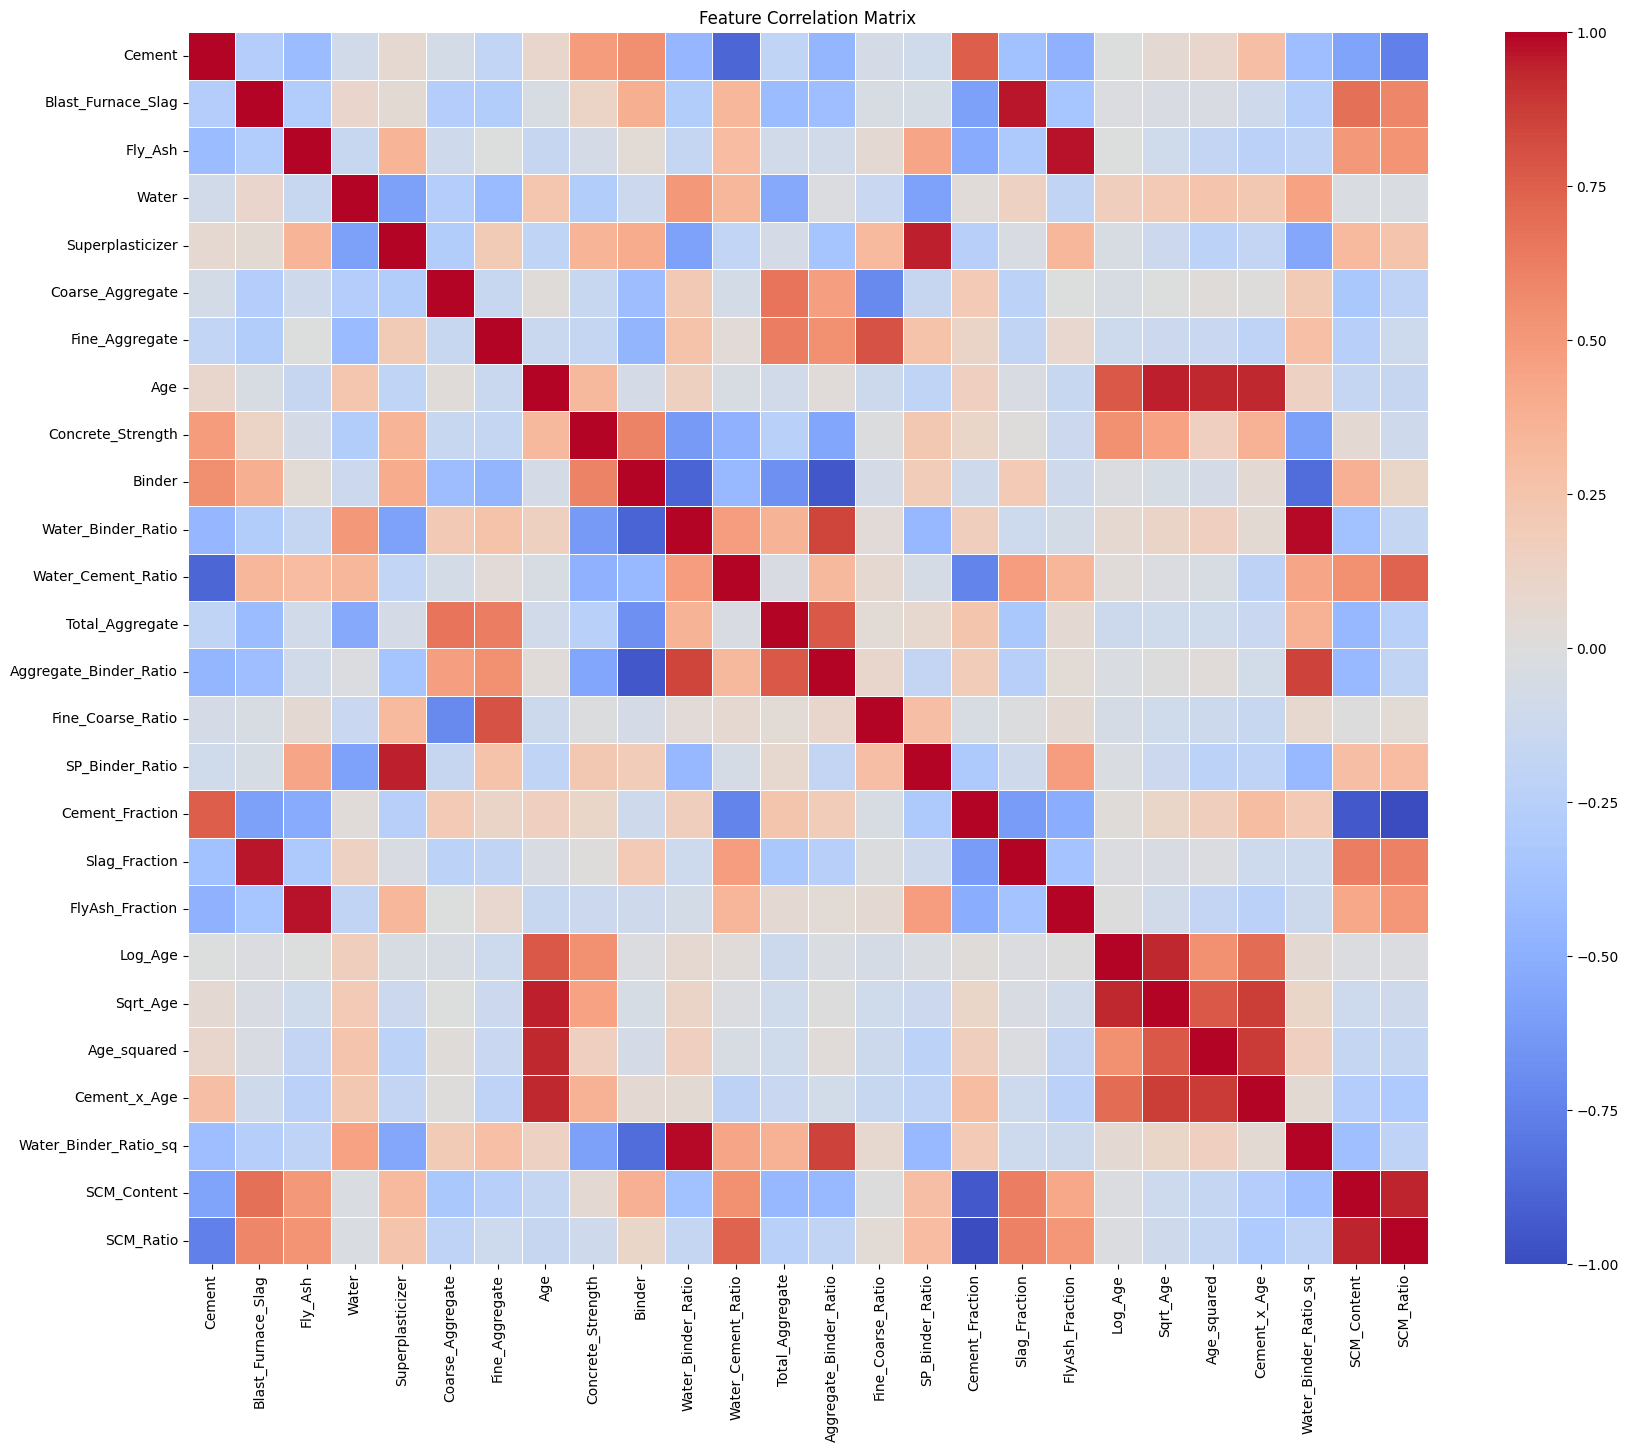

Top correlations with Concrete Strength:
Concrete_Strength         1.000000
Binder                    0.609279
Log_Age                   0.543368
Cement                    0.488592
Sqrt_Age                  0.458113
Cement_x_Age              0.371624
Superplasticizer          0.355506
Age                       0.323860
SP_Binder_Ratio           0.222919
Age_squared               0.162023
Blast_Furnace_Slag        0.119847
Cement_Fraction           0.102641
SCM_Content               0.058696
Slag_Fraction             0.008799
Fine_Coarse_Ratio        -0.013723
Fly_Ash                  -0.064403
SCM_Ratio                -0.102641
FlyAsh_Fraction          -0.131331
Coarse_Aggregate         -0.154845
Fine_Aggregate           -0.165234
Total_Aggregate          -0.245740
Water                    -0.278210
Water_Cement_Ratio       -0.484842
Aggregate_Binder_Ratio   -0.557457
Water_Binder_Ratio_sq    -0.593012
Water_Binder_Ratio       -0.624838
Name: Concrete_Strength, dtype: float64


In [13]:
# correlation matrix
corr_matrix = df.corr()

# heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# correlations with target
target_corr = corr_matrix['Concrete_Strength'].sort_values(ascending=False)
print('Top correlations with Concrete Strength:')
print(target_corr)

In [14]:
# predictor features (exclude target)
x = df.drop('Concrete_Strength', axis=1)

# Adding constant for intercept (required for statsmodels)
from statsmodels.tools.tools import add_constant
X_with_const = add_constant(x)

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

# Removing the constant row for readability
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
print('Variance Inflation Factors:')
print(vif_data)

Variance Inflation Factors:
                   Feature           VIF
25               SCM_Ratio           inf
24             SCM_Content  9.007199e+15
1                   Cement  1.125900e+15
3                  Fly_Ash  8.188363e+14
18         FlyAsh_Fraction  4.289143e+14
16         Cement_Fraction  2.905548e+14
2       Blast_Furnace_Slag  2.573486e+14
7           Fine_Aggregate  2.094698e+14
9                   Binder  1.801440e+14
17           Slag_Fraction  1.286743e+14
6         Coarse_Aggregate  9.501265e+12
12         Total_Aggregate  2.153287e+12
13  Aggregate_Binder_Ratio  5.443568e+03
20                Sqrt_Age  3.021165e+03
10      Water_Binder_Ratio  2.670410e+03
8                      Age  2.480186e+03
23   Water_Binder_Ratio_sq  5.306380e+02
19                 Log_Age  4.641553e+02
4                    Water  2.719081e+02
21             Age_squared  2.233193e+02
14       Fine_Coarse_Ratio  1.178055e+02
5         Superplasticizer  6.742089e+01
15         SP_Binder_Ratio  6

##Insights

1) Severe Multicollinearity Detected -
The VIF results show multiple features with infinite values, including cement, blast furnace slag, fly Ash, binder, total Aggregate, Fraction-based features. This indicates linear dependency because several features are mathematically derived from others. This creates a singular feature space, making linear models unstable.  eg - Binder = Cement + Slag + Fly Ash

2) Feature Engineering Introduced Redundancy - The correlation heatmap clearly shows strong clusters between

*   Binder is highly correlated with Cement, Slag, Fly Ash
*   Fine Aggregate, Coarse Aggregate, Total Aggregate, and their ratios are tightly correlated
*   Age, Log_Age, Sqrt_Age, Age_squared show near-perfect correlation

3) Log_Age is showing strong correlation with strength but in smoother behavior this indicates Concrete strength gain follows a non-linear (logarithmic) trend over time.

4) Cement × Age shows noticeable correlation with strength this indicates hydration-driven strength gain depends on both cement content and curing time.





In [15]:
# Choosing final features (adjusted based on your VIF and correlation analysis)
final_features = [
    'Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
    'Coarse_Aggregate', 'Fine_Aggregate', 'Age','Concrete_Strength', 'Water_Binder_Ratio',
    'Log_Age', 'Cement_x_Age', 'SCM_Ratio',

]

# Create final dataset
df_final = df[final_features]
df_final.head()

#print('Final feature set shape:', df_final.shape)

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength,Water_Binder_Ratio,Log_Age,Cement_x_Age,SCM_Ratio
0,336.0,0.0,0.0,182.0,3.0,986.0,817.0,28,44.864203,0.541667,3.367296,9408.0,0.000000
1,140.1,4.2,215.9,193.9,4.7,1049.5,710.1,28,26.420000,0.538312,3.367296,3922.8,0.611049
2,350.0,0.0,0.0,203.0,0.0,974.0,775.0,14,22.532076,0.580000,2.708050,4900.0,0.000000
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,28,42.080000,0.358000,3.367296,4536.0,0.676000
4,225.0,0.0,0.0,181.0,0.0,1113.0,833.0,7,11.169511,0.804444,2.079442,1575.0,0.000000


##3.8 Summary Statistics



In [16]:
# Check for missing values
print(df_final.isnull().sum())

# Descriptive statistics of all features (including engineered)
df_final.describe()

Cement                0
Blast_Furnace_Slag    0
Fly_Ash               0
Water                 0
Superplasticizer      0
Coarse_Aggregate      0
Fine_Aggregate        0
Age                   0
Concrete_Strength     0
Water_Binder_Ratio    0
Log_Age               0
Cement_x_Age          0
SCM_Ratio             0
dtype: int64


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_Strength,Water_Binder_Ratio,Log_Age,Cement_x_Age,SCM_Ratio
count,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000,1133.000000
mean,276.504590,74.266240,62.807811,182.984687,6.415538,964.833142,770.490335,44.056487,35.837980,0.466787,3.253580,12747.994122,0.326473
std,103.469947,84.246758,71.583164,21.713923,5.796357,82.788223,79.373870,60.441327,16.100509,0.124019,1.059319,20695.657138,0.212693
min,102.000000,0.000000,0.000000,121.750000,0.000000,708.000000,594.000000,1.000000,2.331808,0.235073,0.693147,306.000000,0.000000
25%,190.000000,0.000000,0.000000,167.000000,0.000000,919.000000,720.000000,14.000000,24.393661,0.382796,2.708050,3122.000000,0.200000
50%,266.000000,26.000000,0.000000,185.700000,6.700000,966.800000,777.500000,28.000000,34.673748,0.467500,3.367296,7000.000000,0.338211
75%,342.000000,141.300000,121.970000,193.800000,10.160000,1026.600000,821.000000,28.000000,44.868340,0.550143,3.367296,11970.000000,0.479377
max,540.000000,359.400000,260.000000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225,0.900000,5.902633,173375.000000,0.736000


#4. Exploring Data ( Visualization )

## 4.1 Univariate Analysis (Distributions)

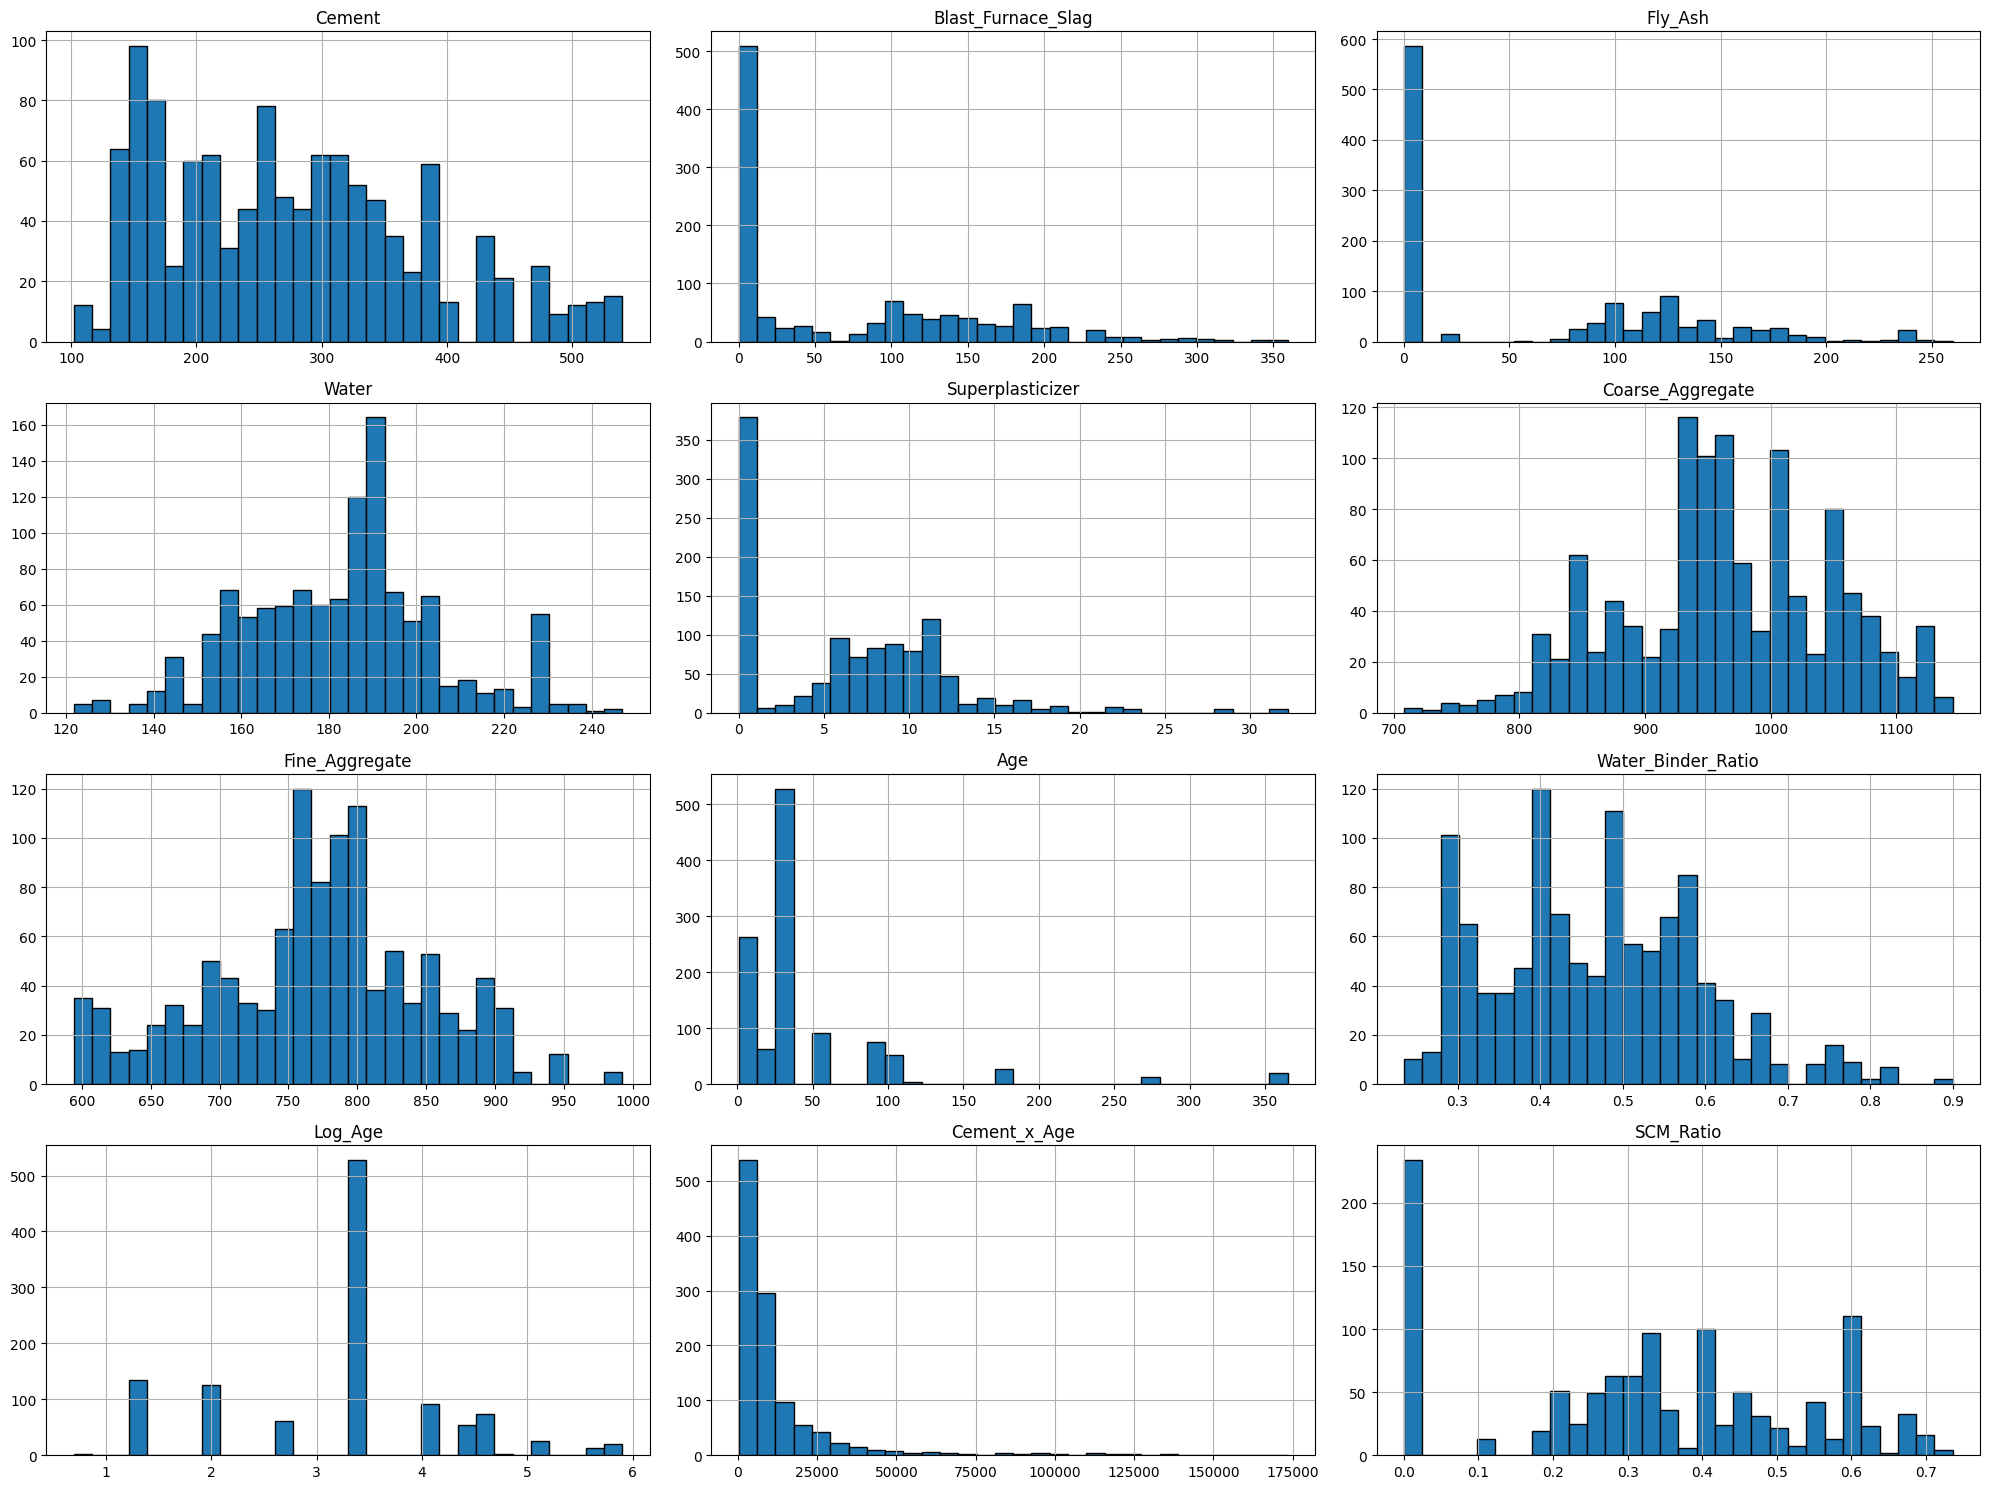

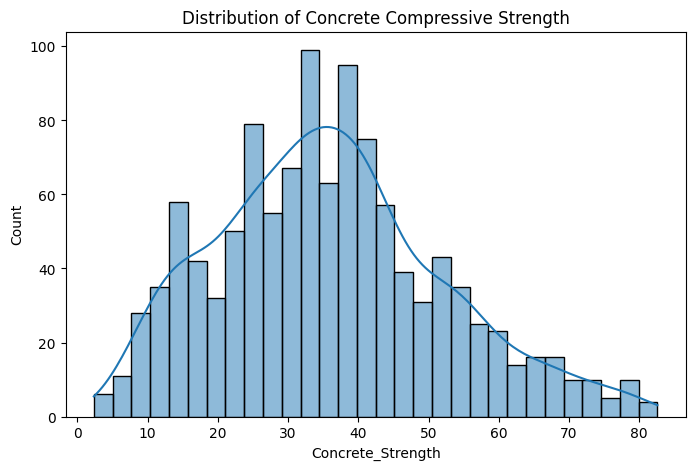

In [17]:
# Selecting columns to plot (original + engineered)
num_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Concrete_Strength')  # target will be plotted separately

# Ploting histograms for all numeric features
df_final[num_cols].hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

# Also ploting the target distribution
plt.figure(figsize=(8,5))
sns.histplot(df_final['Concrete_Strength'], kde=True, bins=30)
plt.title('Distribution of Concrete Compressive Strength')
plt.show()

##Insights
* Several features are skewed and zero-inflated (especially Superplasticizer, Slag, Fly Ash), indicating the need for transformations.

* Age is highly imbalanced toward early curing stages, which may bias predictions for long-term strength.

* Water-Binder Ratio shows a strong and meaningful spread, making it a key predictive feature.

* Engineered features like Log(Age) help capture non-linear behavior, improving model stability.



## 4.2 Correlation Analysis

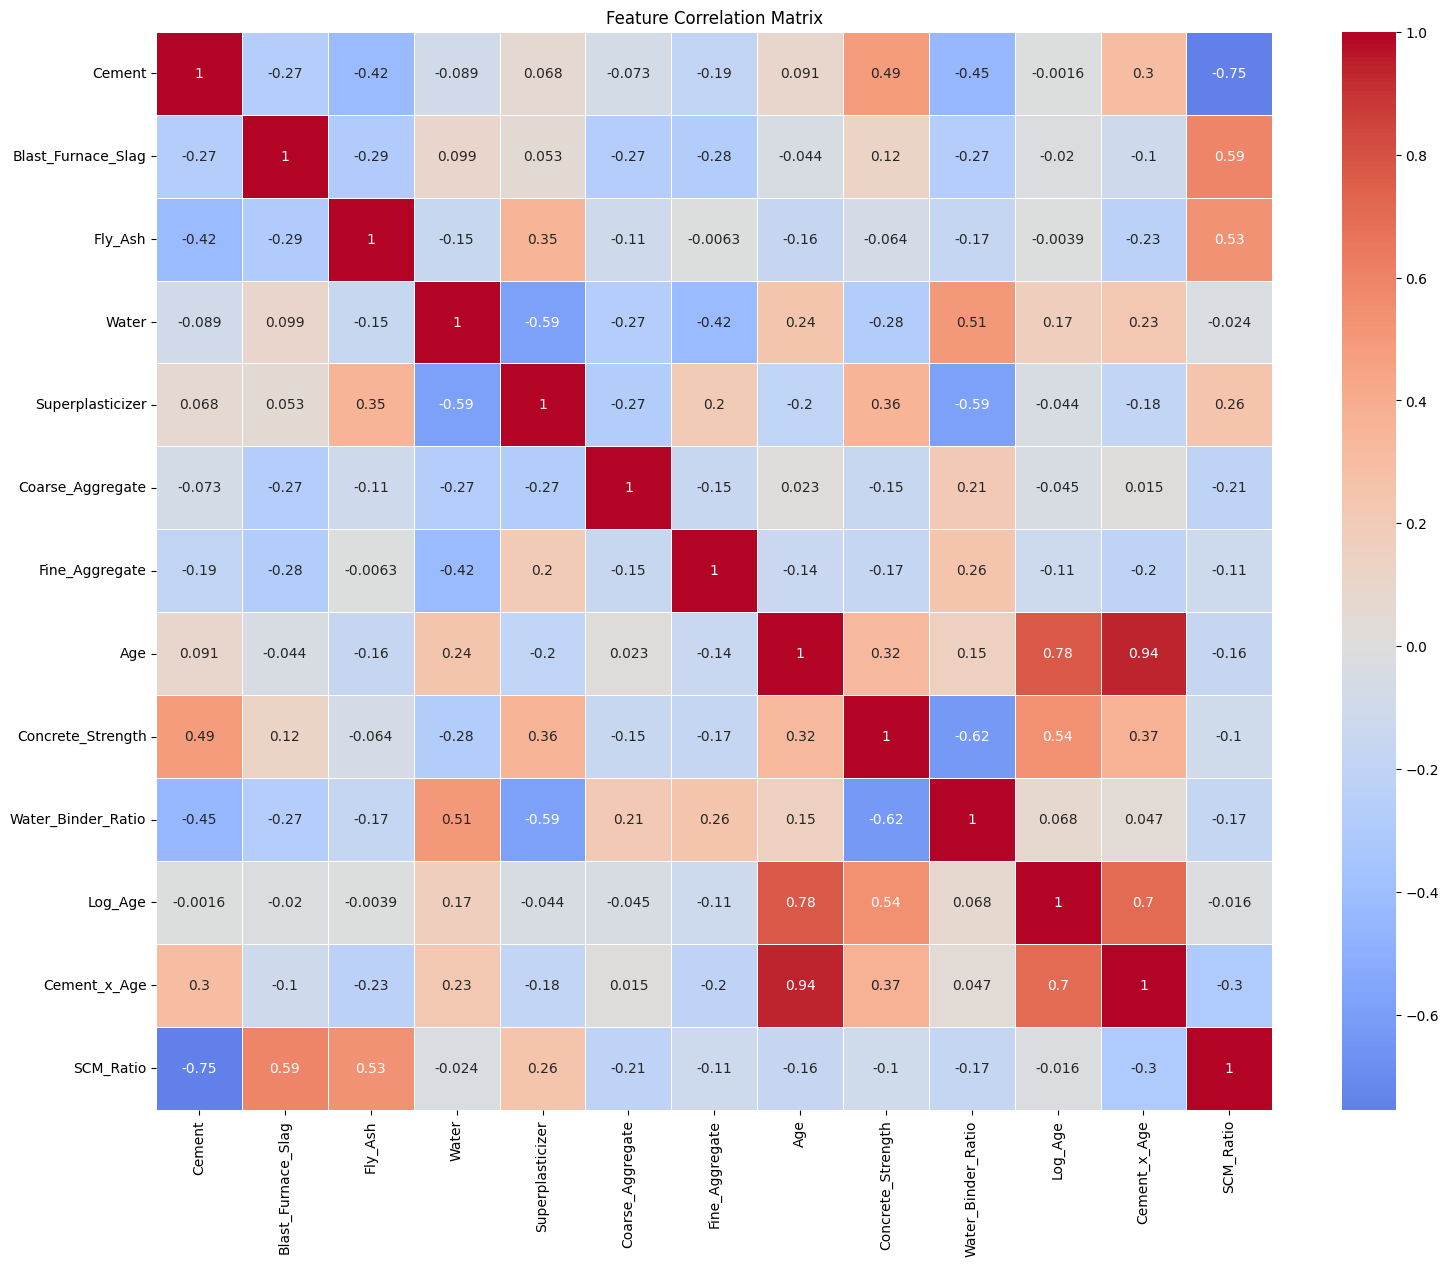

Top correlations with Concrete Strength:
Concrete_Strength     1.000000
Log_Age               0.543368
Cement                0.488592
Cement_x_Age          0.371624
Superplasticizer      0.355506
Age                   0.323860
Blast_Furnace_Slag    0.119847
Fly_Ash              -0.064403
SCM_Ratio            -0.102641
Coarse_Aggregate     -0.154845
Fine_Aggregate       -0.165234
Water                -0.278210
Water_Binder_Ratio   -0.624838
Name: Concrete_Strength, dtype: float64


In [18]:
# Compute correlation matrix including target
corr_matrix = df_final.corr()

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Focus on correlations with the target
target_corr = corr_matrix['Concrete_Strength'].sort_values(ascending=False)
print('Top correlations with Concrete Strength:')
print(target_corr)

## Insights
* Concrete Compressive Strength shows strongest positive correlation with Cement (0.49) and Log(Age) (~0.54), confirming material content and curing time drive strength.

* Water_Binder_Ratio has a strong negative correlation (~-0.62), making it the most critical inverse predictor.

* Age, Log_Age, and Cement × Age are highly correlated → indicates redundancy but also captures time-based strength gain.

* SCM_Ratio is negatively correlated with Cement (~-0.75) and weakly with strength → highlights trade-off between sustainability and strength.

## 4.3 Feature vs Target Relationships

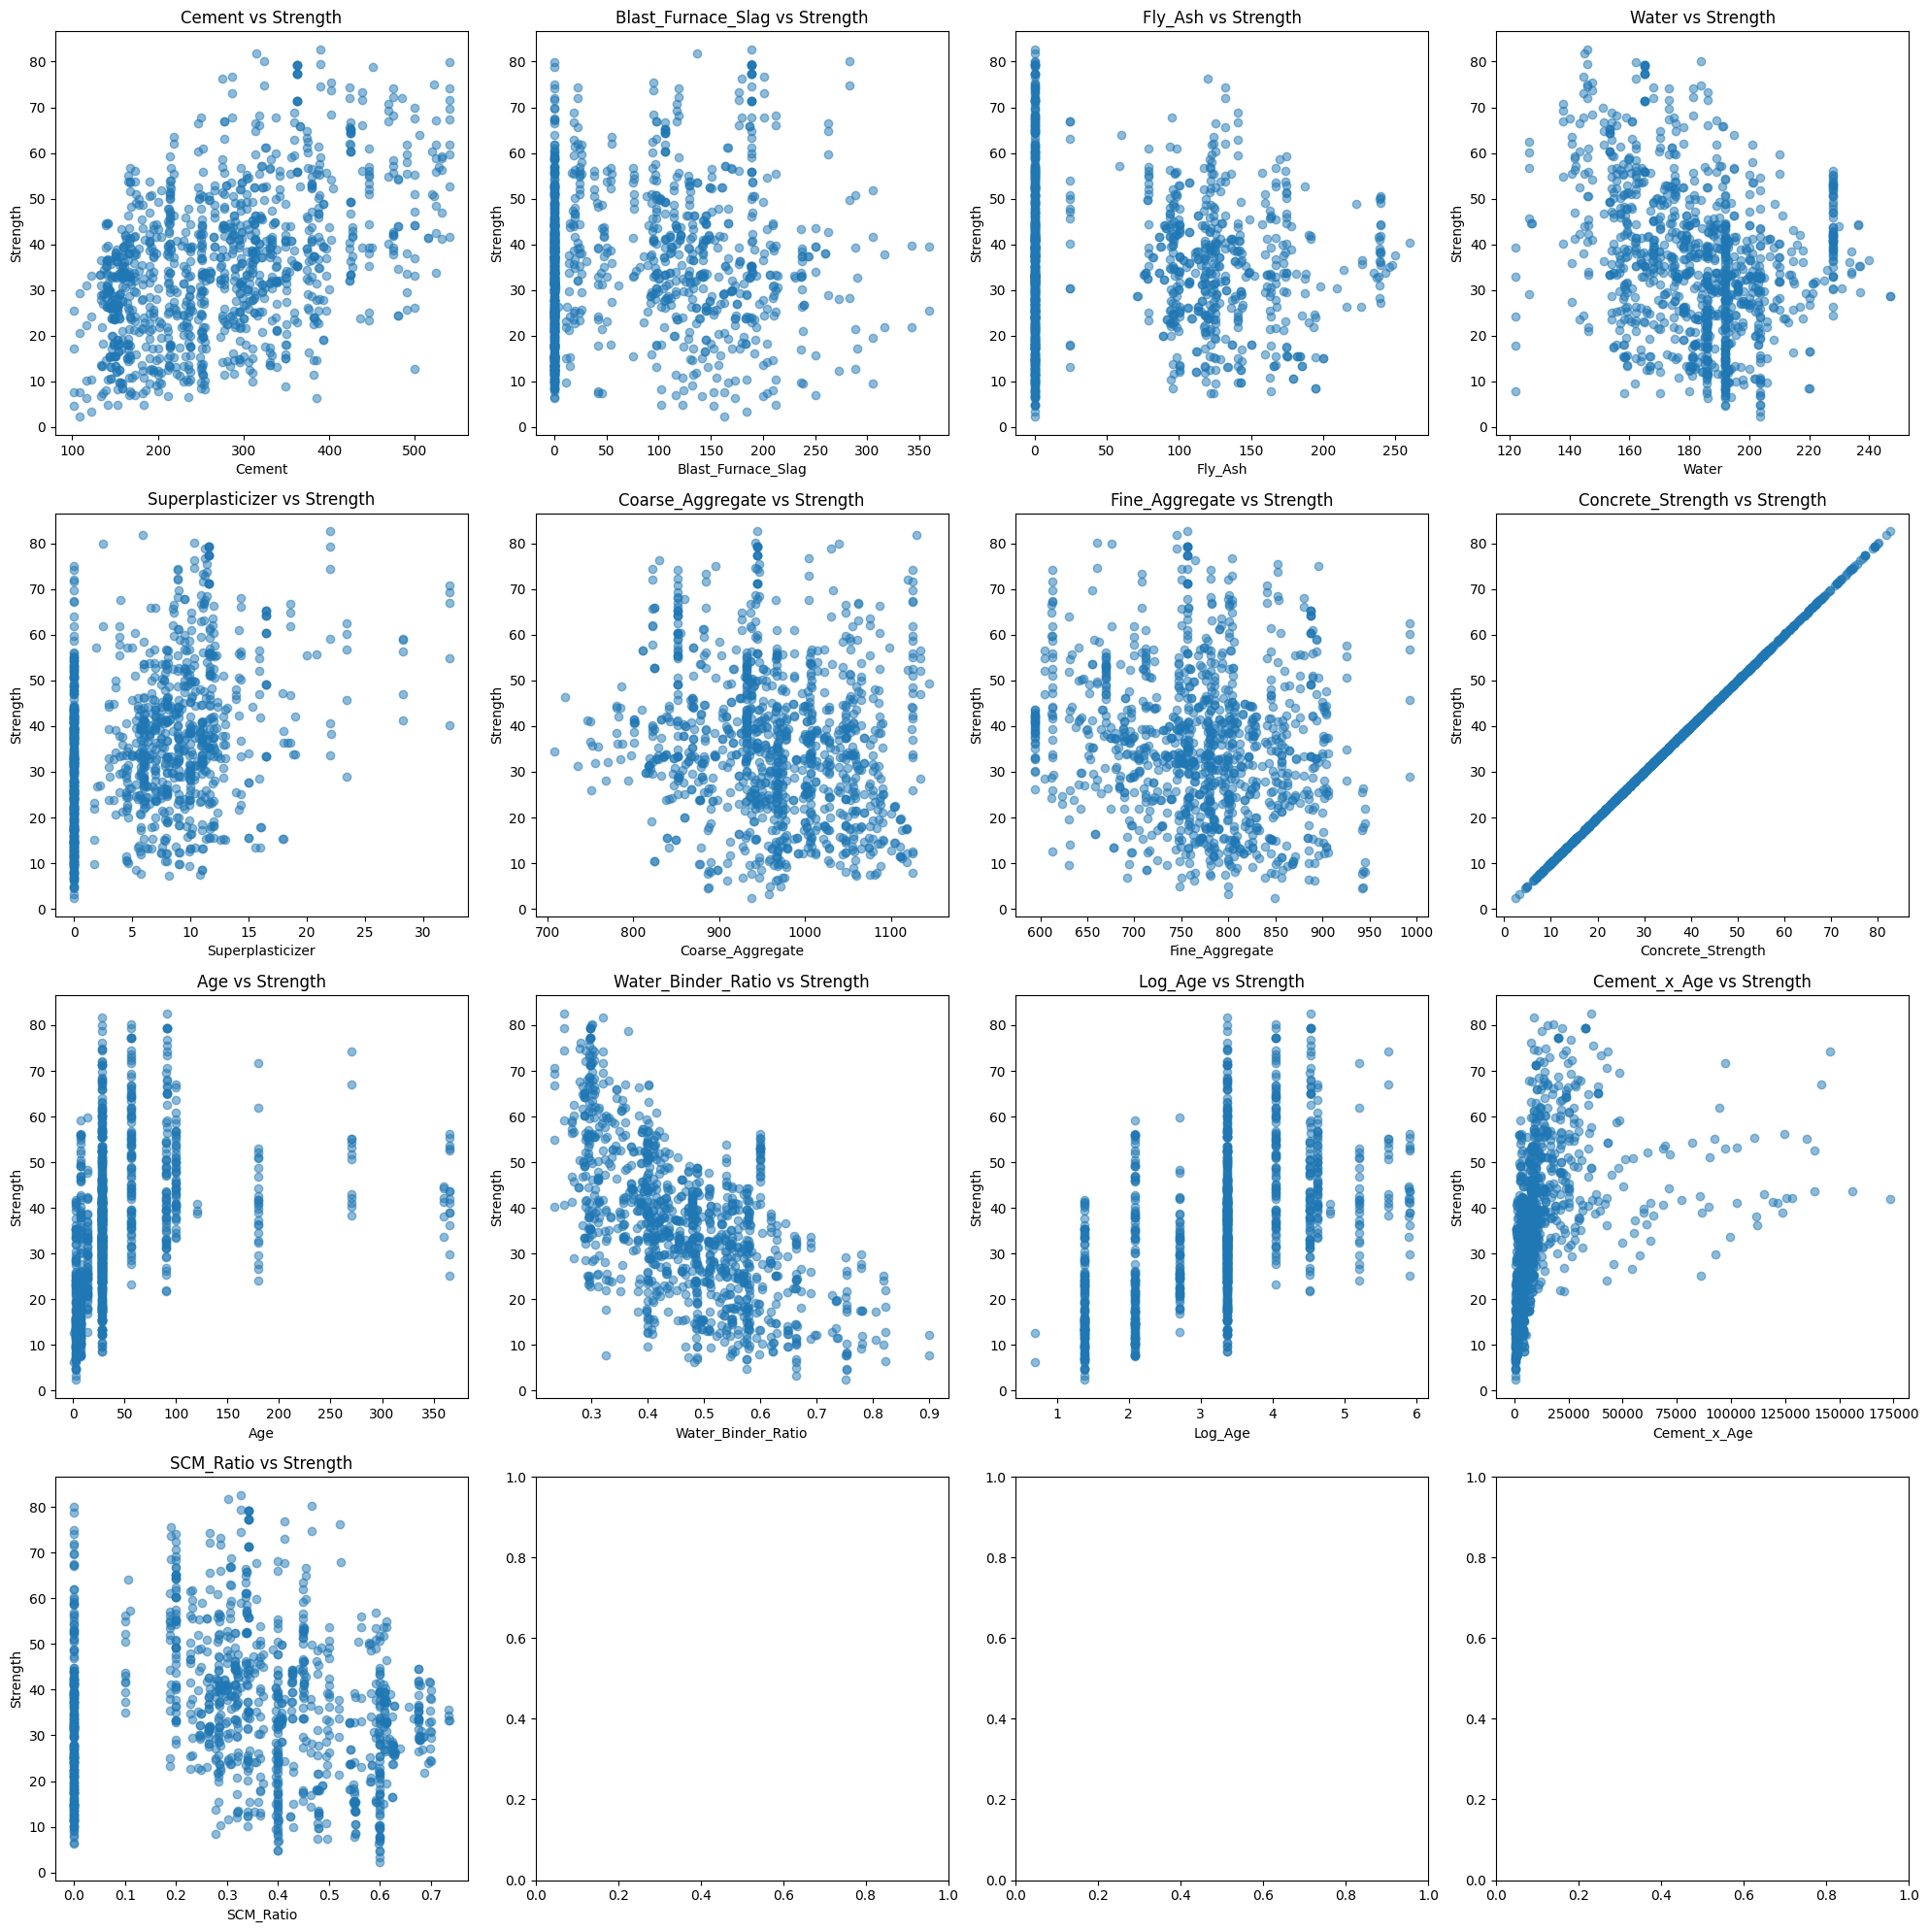

In [19]:
# Creating scatter plots for engineered features vs strength
fig, axes = plt.subplots(4, 4, figsize=(20, 20)) # Changed to 4x4 grid
features_to_plot = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
    'Coarse_Aggregate', 'Fine_Aggregate', 'Concrete_Strength', 'Age', 'Water_Binder_Ratio',
    'Log_Age', 'Cement_x_Age', 'SCM_Ratio']
axes = axes.ravel()

for i, feat in enumerate(features_to_plot):
    if i < len(axes): # Added a check to ensure index is within bounds
        axes[i].scatter(df_final[feat], df['Concrete_Strength'], alpha=0.5)
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('Strength')
        axes[i].set_title(f'{feat} vs Strength')
    else:
        break

plt.tight_layout()
plt.show()

## Insights
* Concrete Compressive Strength increases with Cement and Age, but shows non-linear, scattered patterns → diminishing returns at higher values.

* Water_Binder_Ratio has a clear strong negative relationship, confirming it as the most influential feature.

* Slag and Fly Ash show weak/clustered relationships with many zero values → limited standalone predictive power.

* Cement × Age and Log(Age) capture stronger trends than individual features, highlighting the importance of interaction and non-linearity.

##4.4 Outlier Detection

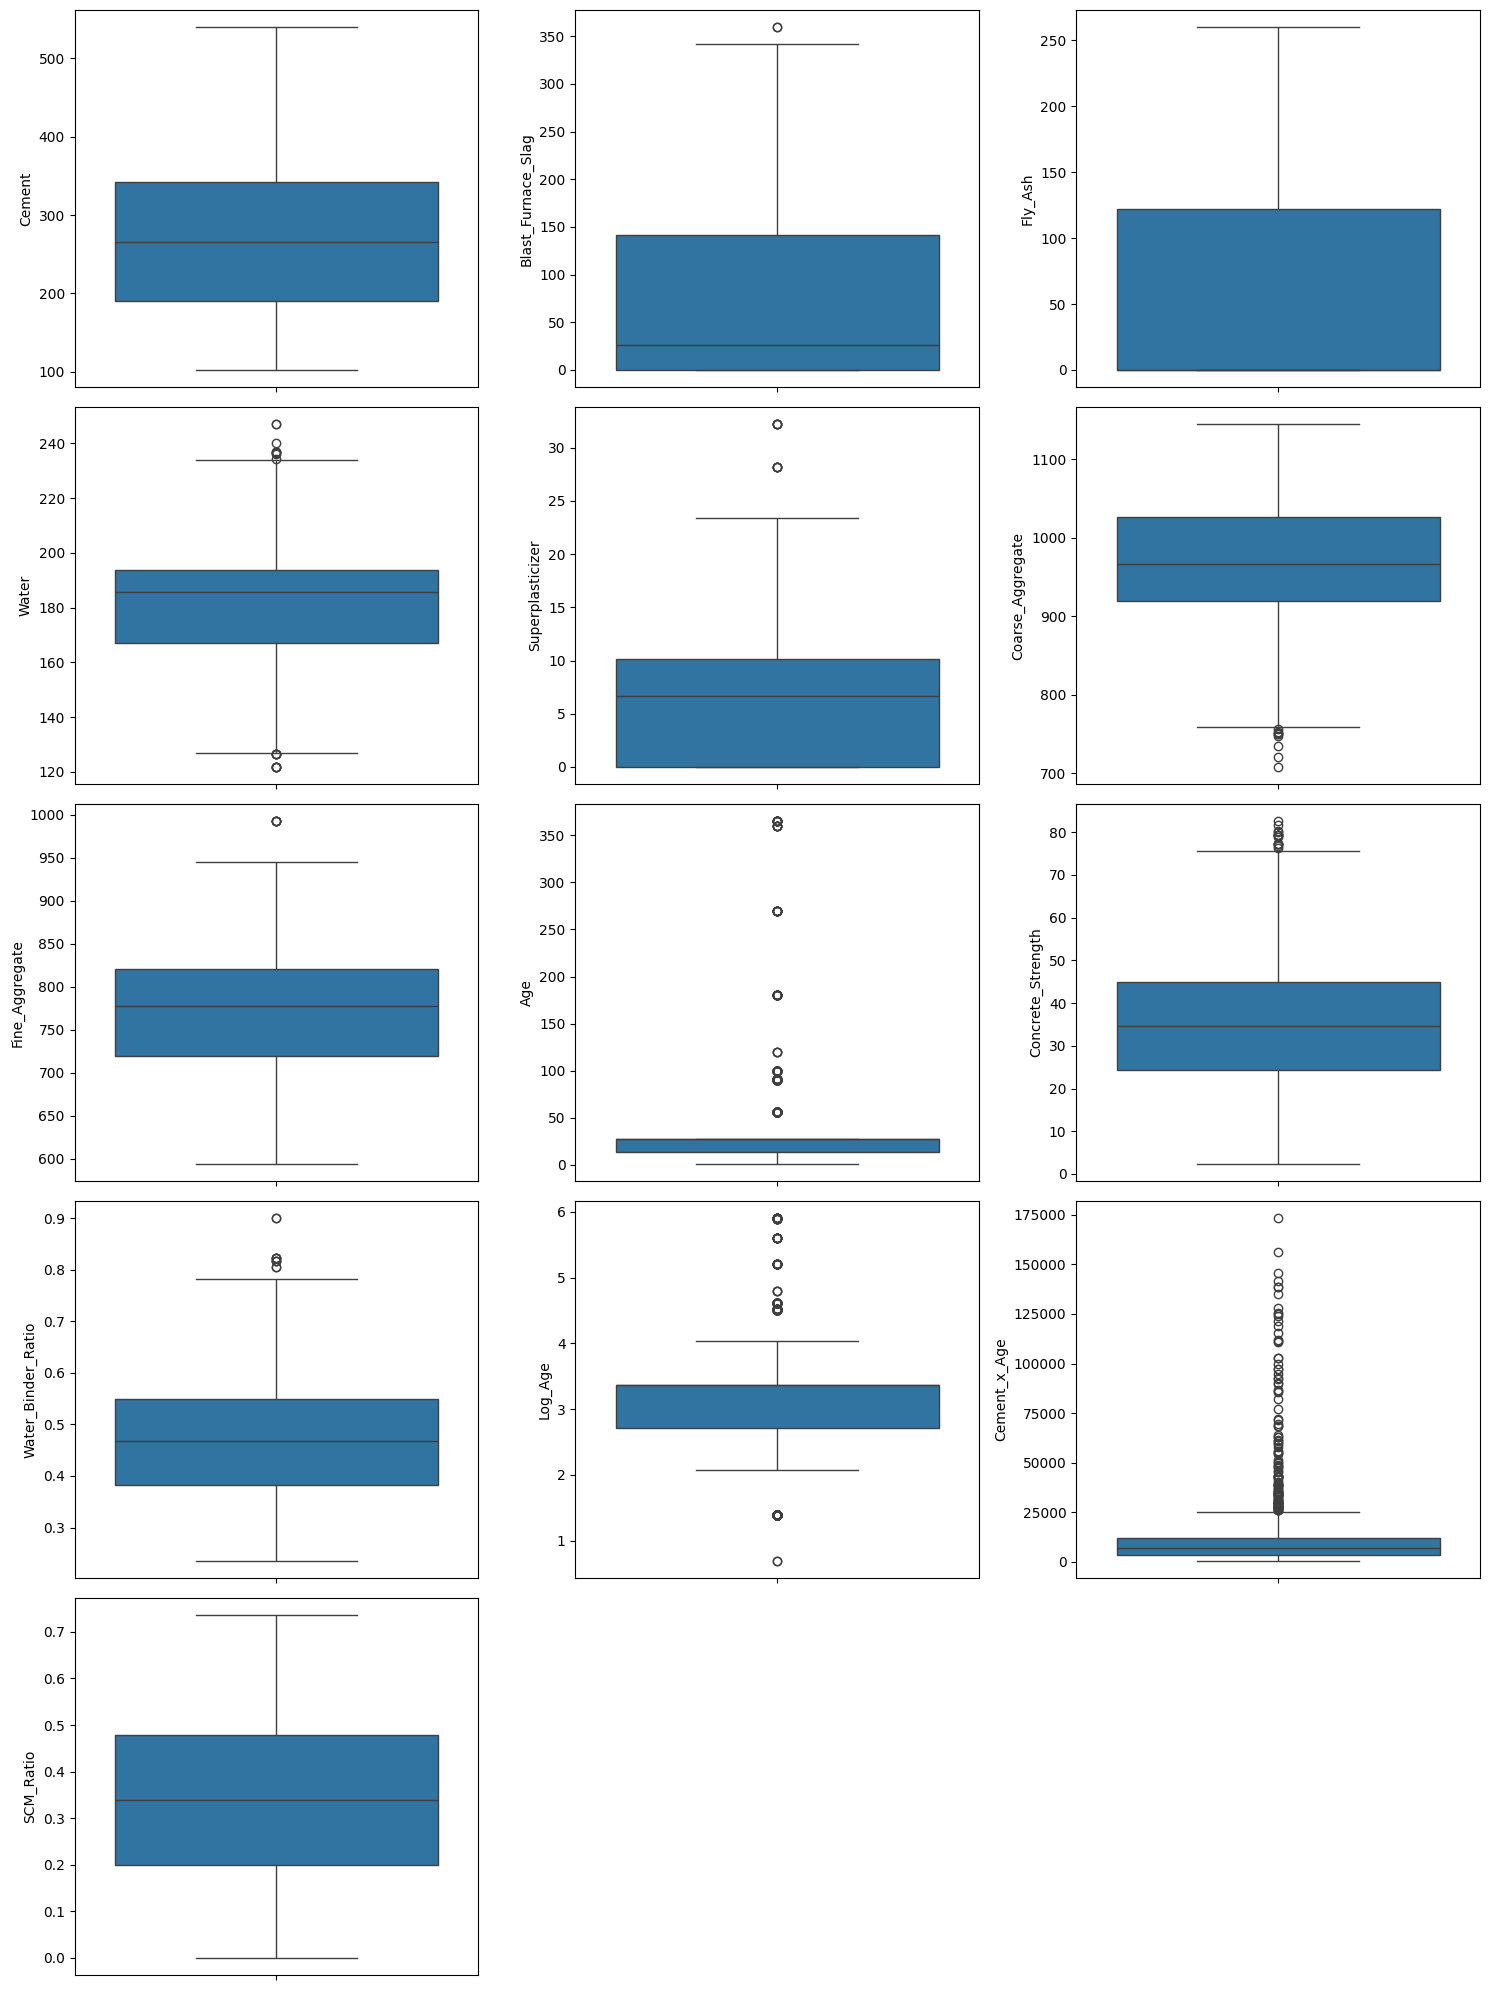

In [20]:
# Selecting features to plot
features = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
            'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_Strength',
            'Water_Binder_Ratio', 'Log_Age', 'Cement_x_Age', 'SCM_Ratio']

fig, axes = plt.subplots(nrows = math.ceil(len(features)/3), ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df_final[col], ax=axes[i])

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Insights


* Outliers: Many features, including Cement, Water, Superplasticizer, Age, Concrete_Strength, Water_Binder_Ratio,  Log_Age, and Cement_x_Age, show a notable presence of outliers, indicated by points beyond the whiskers.
*  Skewness and Zero-Inflation: Features like Blast_Furnace_Slag, Fly_Ash, and Superplasticizer display highly skewed distributions and a significant number of zero values, suggesting their intermittent use or specific dosage patterns.




## Log transformation

* Log transformation was selectively applied to highly skewed features to improve distribution symmetry while preserving the physical interpretability of core variables.



In [21]:
# Create a copy to avoid modifying original data
df_transformed = df_final.copy()

# Applying log1p transformation to skewed features
skewed_features = ['Blast_Furnace_Slag', 'Fly_Ash', 'Superplasticizer']

for col in skewed_features:
    df_transformed[col] = np.log1p(df_transformed[col])

<Figure size 1500x1000 with 0 Axes>

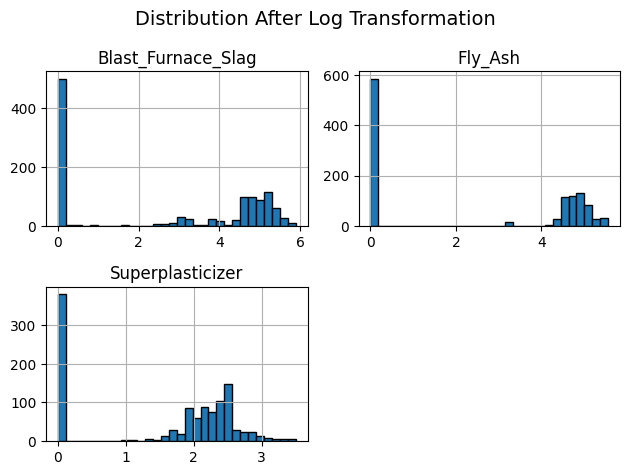

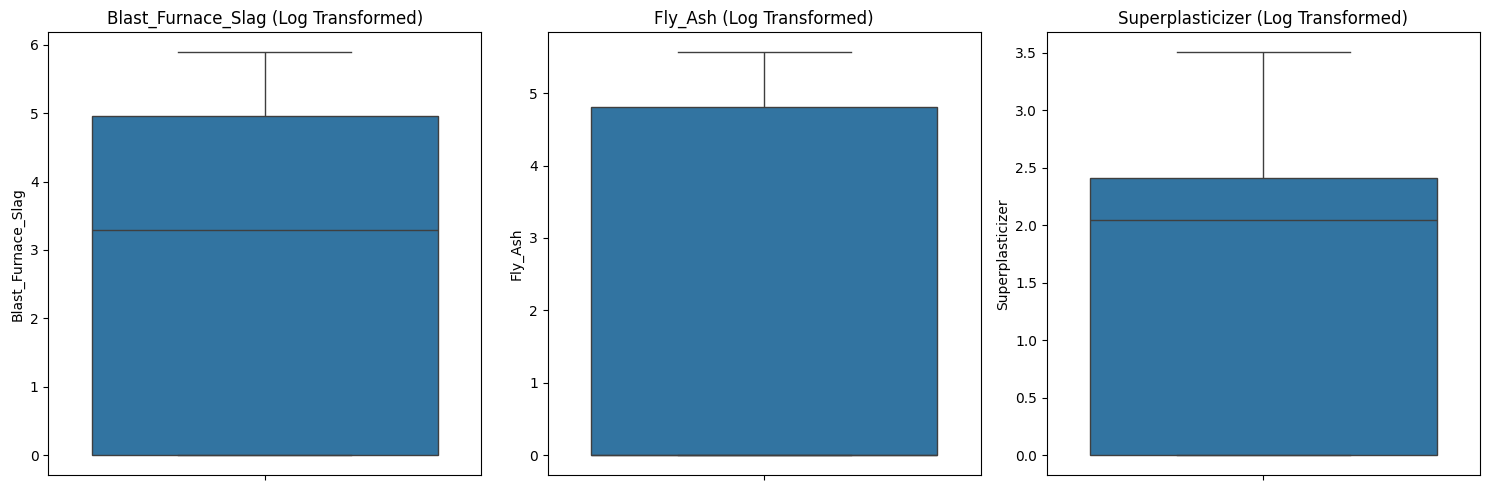

In [22]:
# Visualize distributions after transformation
plt.figure(figsize=(15, 10))
df_transformed[skewed_features].hist(bins=30, edgecolor='black')
plt.suptitle('Distribution After Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

# Boxplots to check spread and outliers
fig, axes = plt.subplots(1, len(skewed_features), figsize=(15, 5))

for i, col in enumerate(skewed_features):
    sns.boxplot(y=df_transformed[col], ax=axes[i])
    axes[i].set_title(f'{col} (Log Transformed)')

plt.tight_layout()
plt.show()

In [25]:
# saving dataset in parquet formate for better Faster read/write, Preserves data types, Compressed, Works well with pipelines
df_transformed.to_parquet("data_transformed.parquet", index=False)